#School Level NYC Regents Report

### The goal of this project is to analyze student test performance

## Import Libraries and Load the Dataset

In [ ]:
import pandas as pd

df = pd.read_csv(
"https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv")
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


## Clean Mean score

In [17]:
# School and exam selected for the analysis
comparison_school_dbn = "01M034"
comparison_school_name = "P.S. 034 Franklin D. Roosevelt"
comparison_exam = "Living Environment"

# Create a copy of the original dataset
df_clean = df.copy()

# Convert Mean Score to numeric
# The value "s" becomes NaN
df_clean["Mean Score"] = pd.to_numeric(
    df_clean["Mean Score"],
    errors="coerce"
)

# Remove missing scores and exact duplicate rows
df_clean = (
    df_clean
    .dropna(subset=["Mean Score"])
    .drop_duplicates()
)

# Filter the selected school and exam
school_df = df_clean[
    (df_clean["School DBN"] == comparison_school_dbn) &
    (df_clean["Regents Exam"] == comparison_exam)
].copy()

school_df[
    ["School Name", "Regents Exam", "Year",
     "Total Tested", "Mean Score"]
]

,School Name,Regents Exam,Year,Total Tested,Mean Score
1,P.S. 034 Franklin D. Roosevelt,Living Environment,2015,16,77.9
2,P.S. 034 Franklin D. Roosevelt,Living Environment,2016,9,74.0
54237,P.S. 034 Franklin D. Roosevelt,Living Environment,2015,10,78.8
102881,P.S. 034 Franklin D. Roosevelt,Living Environment,2015,7,78.0
102882,P.S. 034 Franklin D. Roosevelt,Living Environment,2015,9,77.9
139886,P.S. 034 Franklin D. Roosevelt,Living Environment,2015,6,80.0
139888,P.S. 034 Franklin D. Roosevelt,Living Environment,2015,6,75.5
139892,P.S. 034 Franklin D. Roosevelt,Living Environment,2016,6,73.5


## Describe

In [18]:
school_df["Mean Score"].describe()

,Mean Score
count,8.00000
mean,76.95000
std,2.34033
min,73.50000
25%,75.12500
50%,77.90000
75%,78.20000
max,80.00000


## Compariso

In [19]:
district_code = comparison_school_dbn[:2]

district_df = df_clean[
    (df_clean["School DBN"].str[:2] == district_code) &
    (df_clean["Regents Exam"] == comparison_exam) &
    (df_clean["School DBN"] != comparison_school_dbn)
].copy()

comparison = pd.DataFrame({
    "Group": [
        "P.S. 034 Franklin D. Roosevelt",
        "Other District 01 Schools"
    ],
    "Average Mean Score": [
        school_df["Mean Score"].mean(),
        district_df["Mean Score"].mean()
    ]
}).round(2)

comparison

,Group,Average Mean Score
0,P.S. 034 Franklin D. Roosevelt,76.95
1,Other District 01 Schools,70.16


## Visualization


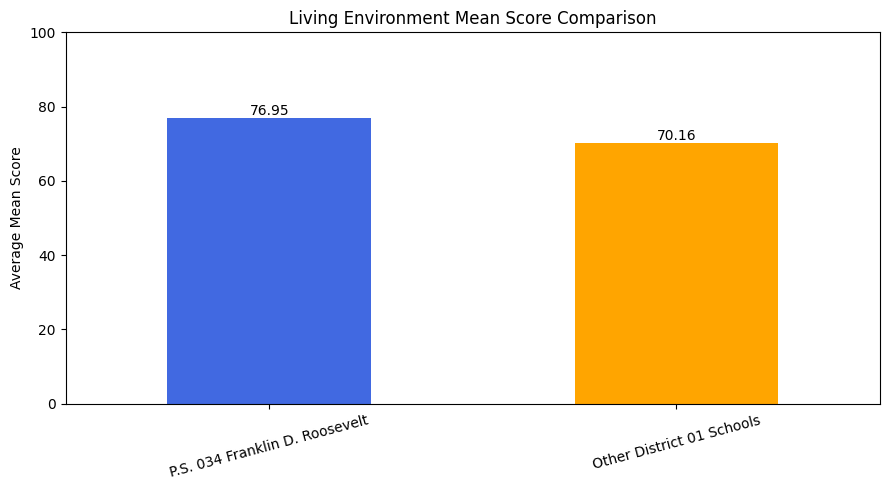

In [20]:
import matplotlib.pyplot as plt

ax = comparison.plot(
    kind="bar",
    x="Group",
    y="Average Mean Score",
    color=["royalblue", "orange"],
    figsize=(9, 5),
    legend=False
)

ax.set_title("Living Environment Mean Score Comparison")
ax.set_xlabel("")
ax.set_ylabel("Average Mean Score")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## New Section